<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 16: Linear Correlation and Regression
**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences  
**Reference:** Chapter 15-16

## 1. Introduction to Bivariate Analysis
Bivariate analysis involves measuring two or more variables within a single sample to determine if they are related.
* **Related Variables:** Variables that vary together in a consistent manner.
* **Functionally Related:** Variables where the value of one can be mathematically predicted by the value of the other.

### Visualizing Data
The first step in detecting a relationship is creating a **scatter plot**.

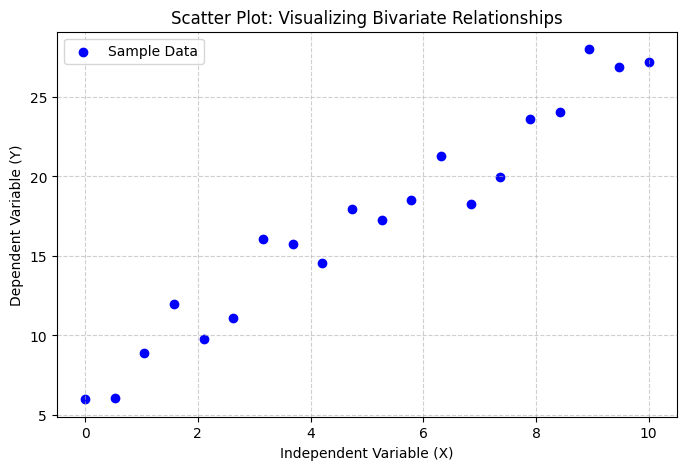

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Generate sample data
np.random.seed(42)
x = np.linspace(0, 10, 20)
y = 2.5 * x + 5 + np.random.normal(0, 2, 20)

# Initial Visualization
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color='blue', label='Sample Data')
plt.title('Scatter Plot: Visualizing Bivariate Relationships')
plt.xlabel('Independent Variable (X)')
plt.ylabel('Dependent Variable (Y)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## 2. Linear Correlation (Pearson's $r$)
Pearson’s $r$ measures the strength and direction of a linear relationship between two variables.
* **Range:** -1.0 (perfect negative) to +1.0 (perfect positive).
* **Formula using Z-scores:**
$$r = \frac{\sum (Z_x Z_y)}{n - 1}$$

In [2]:
def calculate_pearson_r(x, y):
    # Calculate Z-scores
    zx = (x - np.mean(x)) / np.std(x, ddof=1)
    zy = (y - np.mean(y)) / np.std(y, ddof=1)
    # Calculate r
    r = np.sum(zx * zy) / (len(x) - 1)
    return r

r_value = calculate_pearson_r(x, y)
print(f"Calculated Pearson r: {r_value:.4f}")

Calculated Pearson r: 0.9747


## 3. Linear Regression
Regression describes a **functional relationship** to predict $Y$ from $X$.
The line of best fit is:
$$Y = a + bX$$
* **$b$ (Slope):** The average change in $Y$ for every one-unit increase in $X$.
* **$a$ (Intercept):** The value of $Y$ when $X = 0$.

### Significance and $r^2$
* **$r^2$ (Coefficient of Determination):** The proportion of variation in $Y$ explained by the regression line.
* **Statistical Significance:** We test if the population slope ($\beta$) is significantly different from zero using an F-test.

In [3]:
# Using scipy to perform regression
slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)

print(f"Regression Equation: Y = {intercept:.2f} + {slope:.2f}X")
print(f"r-squared: {r_val**2:.4f}")
print(f"p-value: {p_val:.4e}") # If < 0.05, the relationship is significant

Regression Equation: Y = 6.55 + 2.12X
r-squared: 0.9500
p-value: 3.7319e-13


## 4. Real-World Example 1: Radioactive Decay (Linearization)
Radioactive decay is exponential: $N = N_0 e^{-\lambda t}$. To use linear regression, we take the natural log ($\ln$) of both sides to "linearize" the data:
$$\ln(N) = \ln(N_0) - \lambda t$$
* **New Y:** $\ln(N)$
* **New X:** $t$
* **Slope ($b$):** $-\lambda$ (the decay constant)

Estimated Decay Constant (lambda): 0.3398
Estimated Initial Count (N0): 1002.71


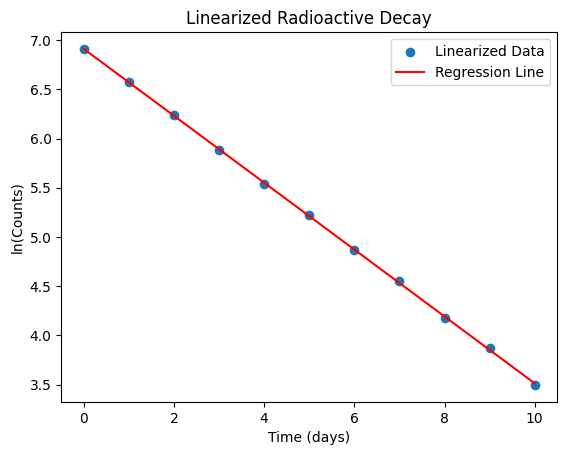

In [4]:
# Time (days) vs. Measured Isotope Counts
time = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
counts = np.array([1000, 715, 510, 360, 255, 185, 130, 95, 65, 48, 33])

# Linearize data
ln_counts = np.log(counts)

# Perform regression on linearized data
slope_d, intercept_d, r_d, p_d, err_d = stats.linregress(time, ln_counts)

print(f"Estimated Decay Constant (lambda): {-slope_d:.4f}")
print(f"Estimated Initial Count (N0): {np.exp(intercept_d):.2f}")

# Plot
plt.scatter(time, ln_counts, label='Linearized Data')
plt.plot(time, intercept_d + slope_d*time, color='red', label='Regression Line')
plt.title('Linearized Radioactive Decay')
plt.xlabel('Time (days)')
plt.ylabel('ln(Counts)')
plt.legend()
plt.show()

## 5. Real-World Example 2: Atmospheric Lapse Rate
As elevation increases, temperature decreases. This linear relationship is known as the **Environmental Lapse Rate**.

Lapse Rate: 6.53 °C per km
r-squared: 0.9982


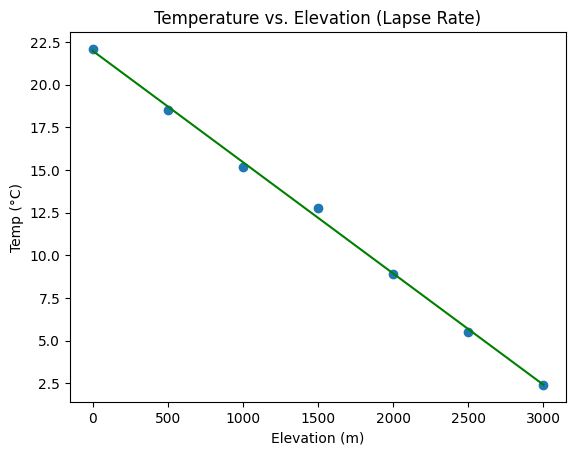

In [5]:
# Elevation (meters) vs Temperature (Celsius)
elevation = np.array([0, 500, 1000, 1500, 2000, 2500, 3000])
temp = np.array([22.1, 18.5, 15.2, 12.8, 8.9, 5.5, 2.4])

slope_l, intercept_l, r_l, p_l, err_l = stats.linregress(elevation, temp)

print(f"Lapse Rate: {abs(slope_l)*1000:.2f} °C per km")
print(f"r-squared: {r_l**2:.4f}")

plt.scatter(elevation, temp)
plt.plot(elevation, intercept_l + slope_l*elevation, color='green')
plt.title('Temperature vs. Elevation (Lapse Rate)')
plt.xlabel('Elevation (m)')
plt.ylabel('Temp (°C)')
plt.show()

## 6. Real-World Example 3: Tectonic Plate Motion
Using GPS data of a plate's distance from a fixed point over several years to calculate the velocity of plate motion ($V = \text{distance} / \text{time}$).

Plate Velocity: 34.71 mm/year
Standard Error of Velocity: 0.1724 mm/year


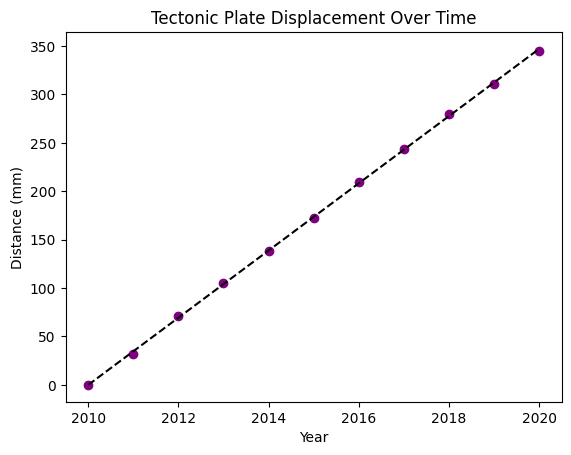

In [6]:
# Years vs Distance Moved (mm)
years = np.array([2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020])
dist = np.array([0, 32, 71, 105, 138, 172, 210, 244, 280, 311, 345])

slope_v, intercept_v, r_v, p_v, err_v = stats.linregress(years, dist)

print(f"Plate Velocity: {slope_v:.2f} mm/year")
print(f"Standard Error of Velocity: {err_v:.4f} mm/year")

plt.scatter(years, dist, color='purple')
plt.plot(years, intercept_v + slope_v*years, color='black', linestyle='--')
plt.title('Tectonic Plate Displacement Over Time')
plt.xlabel('Year')
plt.ylabel('Distance (mm)')
plt.show()